In [88]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [33]:
df = pd.read_csv('Churn_Modelling.csv')

In [34]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [35]:
df.drop('CustomerId',axis=1, inplace=True)

In [36]:
df.drop('Surname', axis=1, inplace=True)

In [37]:
df.drop('RowNumber', axis=1, inplace=True)

In [38]:
X = df.drop(columns='Exited')
y = df['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [39]:
categorical_features = X.select_dtypes(include=['str']).columns.tolist()

for feature in categorical_features:
    print(X[feature].value_counts())
    print("*"*50)

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
**************************************************
Gender
Male      5457
Female    4543
Name: count, dtype: int64
**************************************************


In [40]:
numerical_features = X.select_dtypes(include=['int64']).columns.tolist()

for feature in numerical_features:
    print(X[feature].value_counts())
    print("*"*50)

CreditScore
850    233
678     63
655     54
667     53
705     53
      ... 
367      1
412      1
382      1
373      1
419      1
Name: count, Length: 460, dtype: int64
**************************************************
Age
37    478
38    477
35    474
36    456
34    447
     ... 
92      2
82      1
88      1
85      1
83      1
Name: count, Length: 70, dtype: int64
**************************************************
Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64
**************************************************
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
**************************************************
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
**************************************************
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
**************************************************


In [41]:
numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('onehotencoder', OneHotEncoder(handle_unknown='ignore'))
])

In [42]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [44]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


In [50]:
model = Sequential()

model.add(Dense(3, activation='sigmoid', input_dim=11))
model.add(Dense(1, activation='sigmoid'))

c:\Users\TGX-100\anaconda3\envs\tf_gpu\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [78]:
model = Sequential([
    Input(shape=(11,)),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [79]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [80]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [86]:
history = model.fit(X_train_processed, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8591 - loss: 0.3391 - val_accuracy: 0.8731 - val_loss: 0.3404
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8575 - loss: 0.3389 - val_accuracy: 0.8756 - val_loss: 0.3412
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8597 - loss: 0.3385 - val_accuracy: 0.8756 - val_loss: 0.3404
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8603 - loss: 0.3386 - val_accuracy: 0.8712 - val_loss: 0.3404
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8584 - loss: 0.3391 - val_accuracy: 0.8750 - val_loss: 0.3405
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8586 - loss: 0.3384 - val_accuracy: 0.8744 - val_loss: 0.3405
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8586 - loss: 0.3388 - val_accuracy: 0.8694 - val_loss: 0.3419
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8583 - loss: 0.3391 - val_accu

In [82]:
y_pred = model.predict(X_test_processed)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [83]:
y_pred_processed = np.where(y_pred>0.5, 1, 0)

In [85]:
accuracy_score(y_test, y_pred_processed)

0.8635

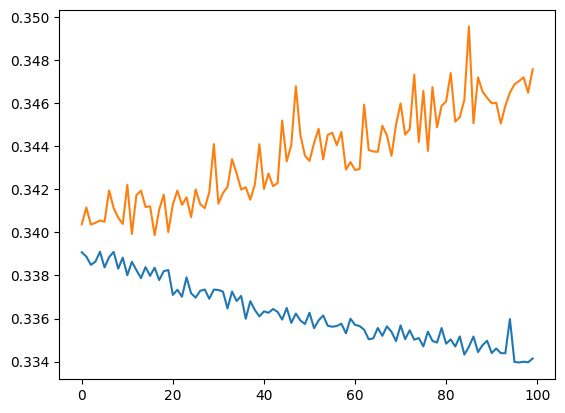

In [93]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

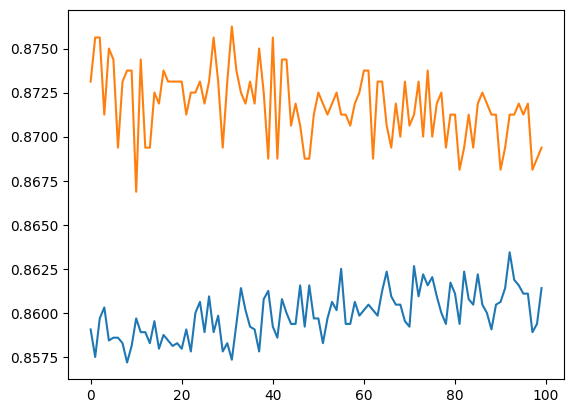

In [95]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')